[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/StarTrail-org/PixelRAG/blob/main/demos/quickstart.ipynb)

# PixelRAG — Quickstart

Visual Retrieval-Augmented Generation: render documents as **screenshots**, search them as **images**. This notebook shows both, with the actual pictures.

```bash
pip install pixelrag
```

In [6]:
# One-time setup (~1 min). Needs Python >= 3.12 (Colab's default runtime).
# pixelshot's headless-Chrome renderer also needs a few system libs on a
# fresh Colab/Linux VM; the hosted search API needs nothing.
%pip install -q pixelrag

import shutil
import subprocess
import sys

if sys.platform == "linux" and shutil.which("apt-get"):
    libs = (
        "libnss3 libatk-bridge2.0-0 libcups2 libdrm2 libxkbcommon0 "
        "libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libasound2"
    )
    subprocess.run(f"apt-get -qq install -y {libs}", shell=True, check=False)

print("ready")

ready


## 1. Render any page to screenshot tiles

The `pixelshot` command turns a URL into tiled JPEG screenshots — the visual form PixelRAG indexes and reads. (First run downloads a headless Chrome.)

rendered → demo_tiles/trends.google.com_explore.png.tiles/tile_0000.jpg


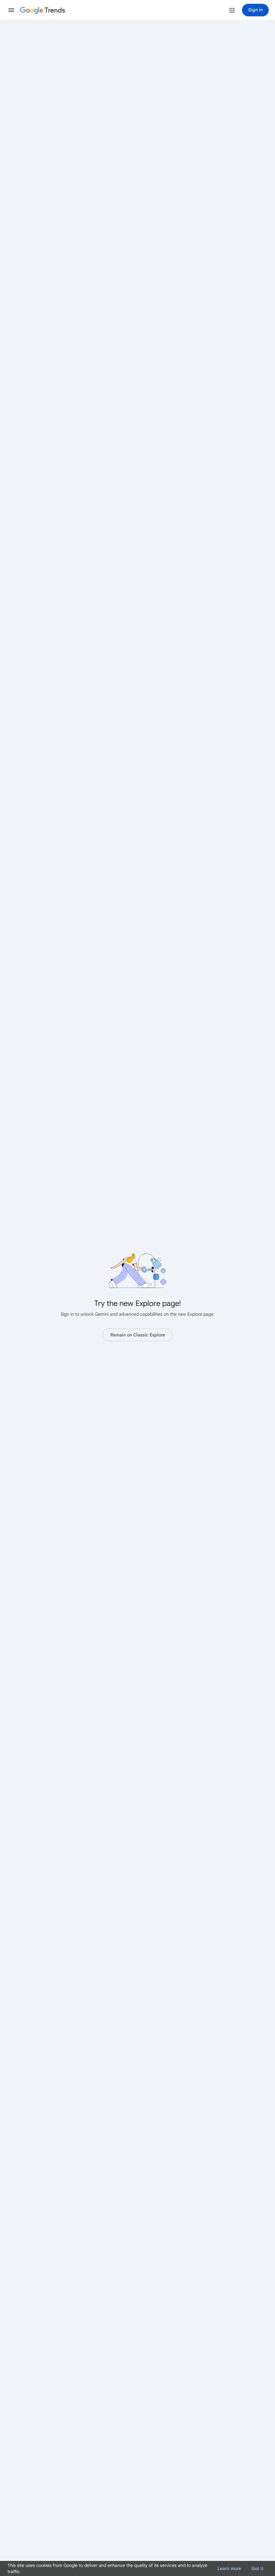

In [7]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

subprocess.run(
    [
        "pixelshot",
        "https://www.rtvslo.si/okolje/vrocina-se-bo-v-naslednjih-dneh-se-stopnjevala-konec-tedna-se-lahko-ponekod-ogreje-tudi-do-40-c/786317",
        "--output",
        "./demo_tiles",
    ],
    check=True,
)
first_tile = sorted(Path("./demo_tiles").glob("*/tile_*.jpg"))[0]
print("rendered →", first_tile)
display(Image(filename=str(first_tile), width=520))

## 2. Search the hosted Wikipedia index

Query the live API (8.28M pages) — in any language. Each hit returns tile coordinates; fetch the tile to **see** the matching screenshot.

0.524  Terracotta_Army


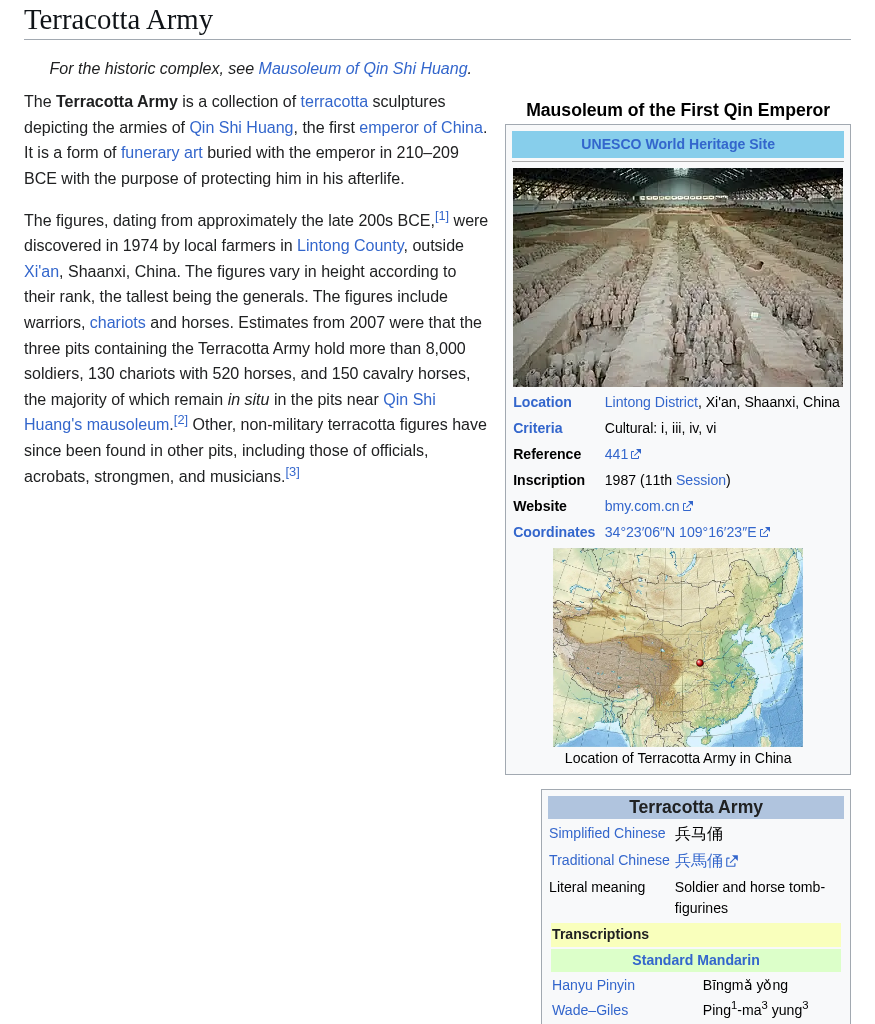

0.478  Taerpo_Horserider


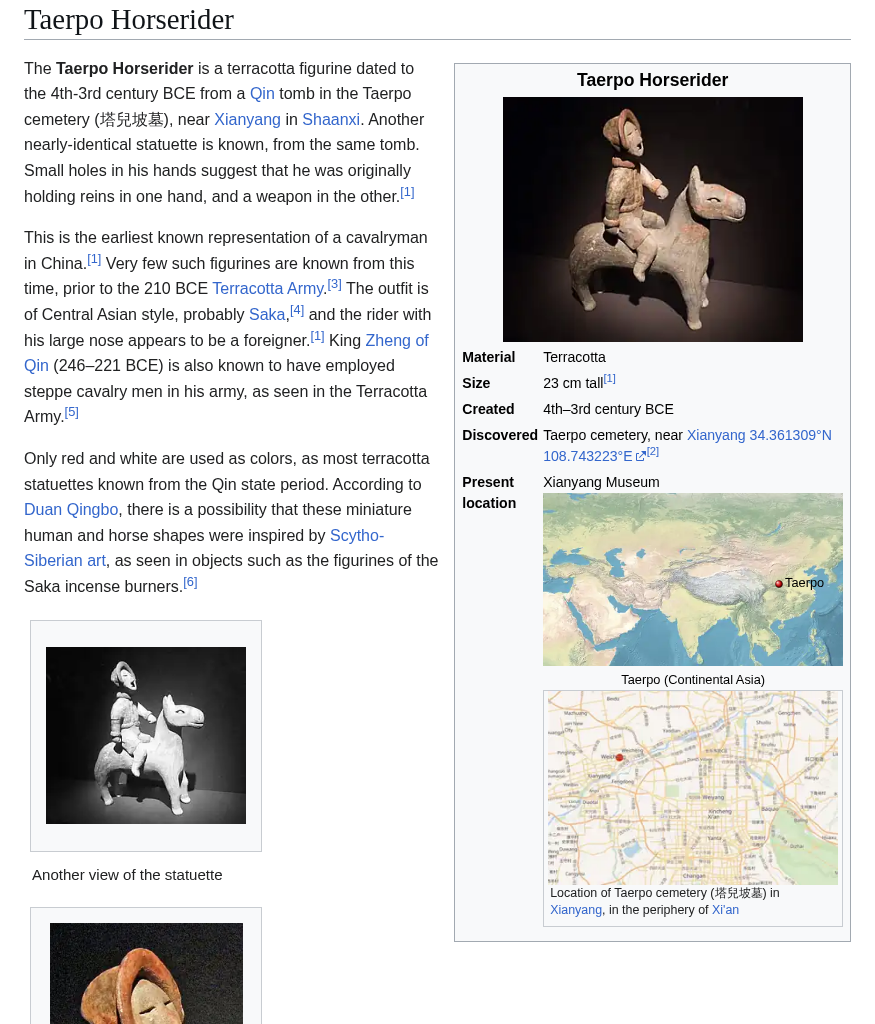

In [ ]:
import requests
from IPython.display import Image, display

API = "https://api.pixelrag.ai"
hits = requests.post(
    f"{API}/search", json={"queries": [{"text": "兵马俑"}], "n_docs": 2}
).json()["results"][0]["hits"]

for h in hits:
    print(f"{h['score']:.3f}  {h['url']}")
    tile = f"{API}/tile/{h['article_id']}/{h['tile_index']}/{h['chunk_index']}"
    display(
        Image(data=requests.get(tile).content, width=420)
    )  # embed so it shows on GitHub